In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

import statsmodels.api as sm
import statsmodels.formula.api as smf

import polars as pl

In [ ]:
df = pl.read_csv('auto-mpg.csv')
dfpa = df.to_pandas().reset_index(drop=True)
df.head()
dfpa.head(100)


,,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...,...
95,95,12.0,8,455.0,225,4951,11.0,73,1,buick electra 225 custom
96,96,13.0,8,360.0,175,3821,11.0,73,1,amc ambassador brougham
97,97,18.0,6,225.0,105,3121,16.5,73,1,plymouth valiant
98,98,16.0,6,250.0,100,3278,18.0,73,1,chevrolet nova custom


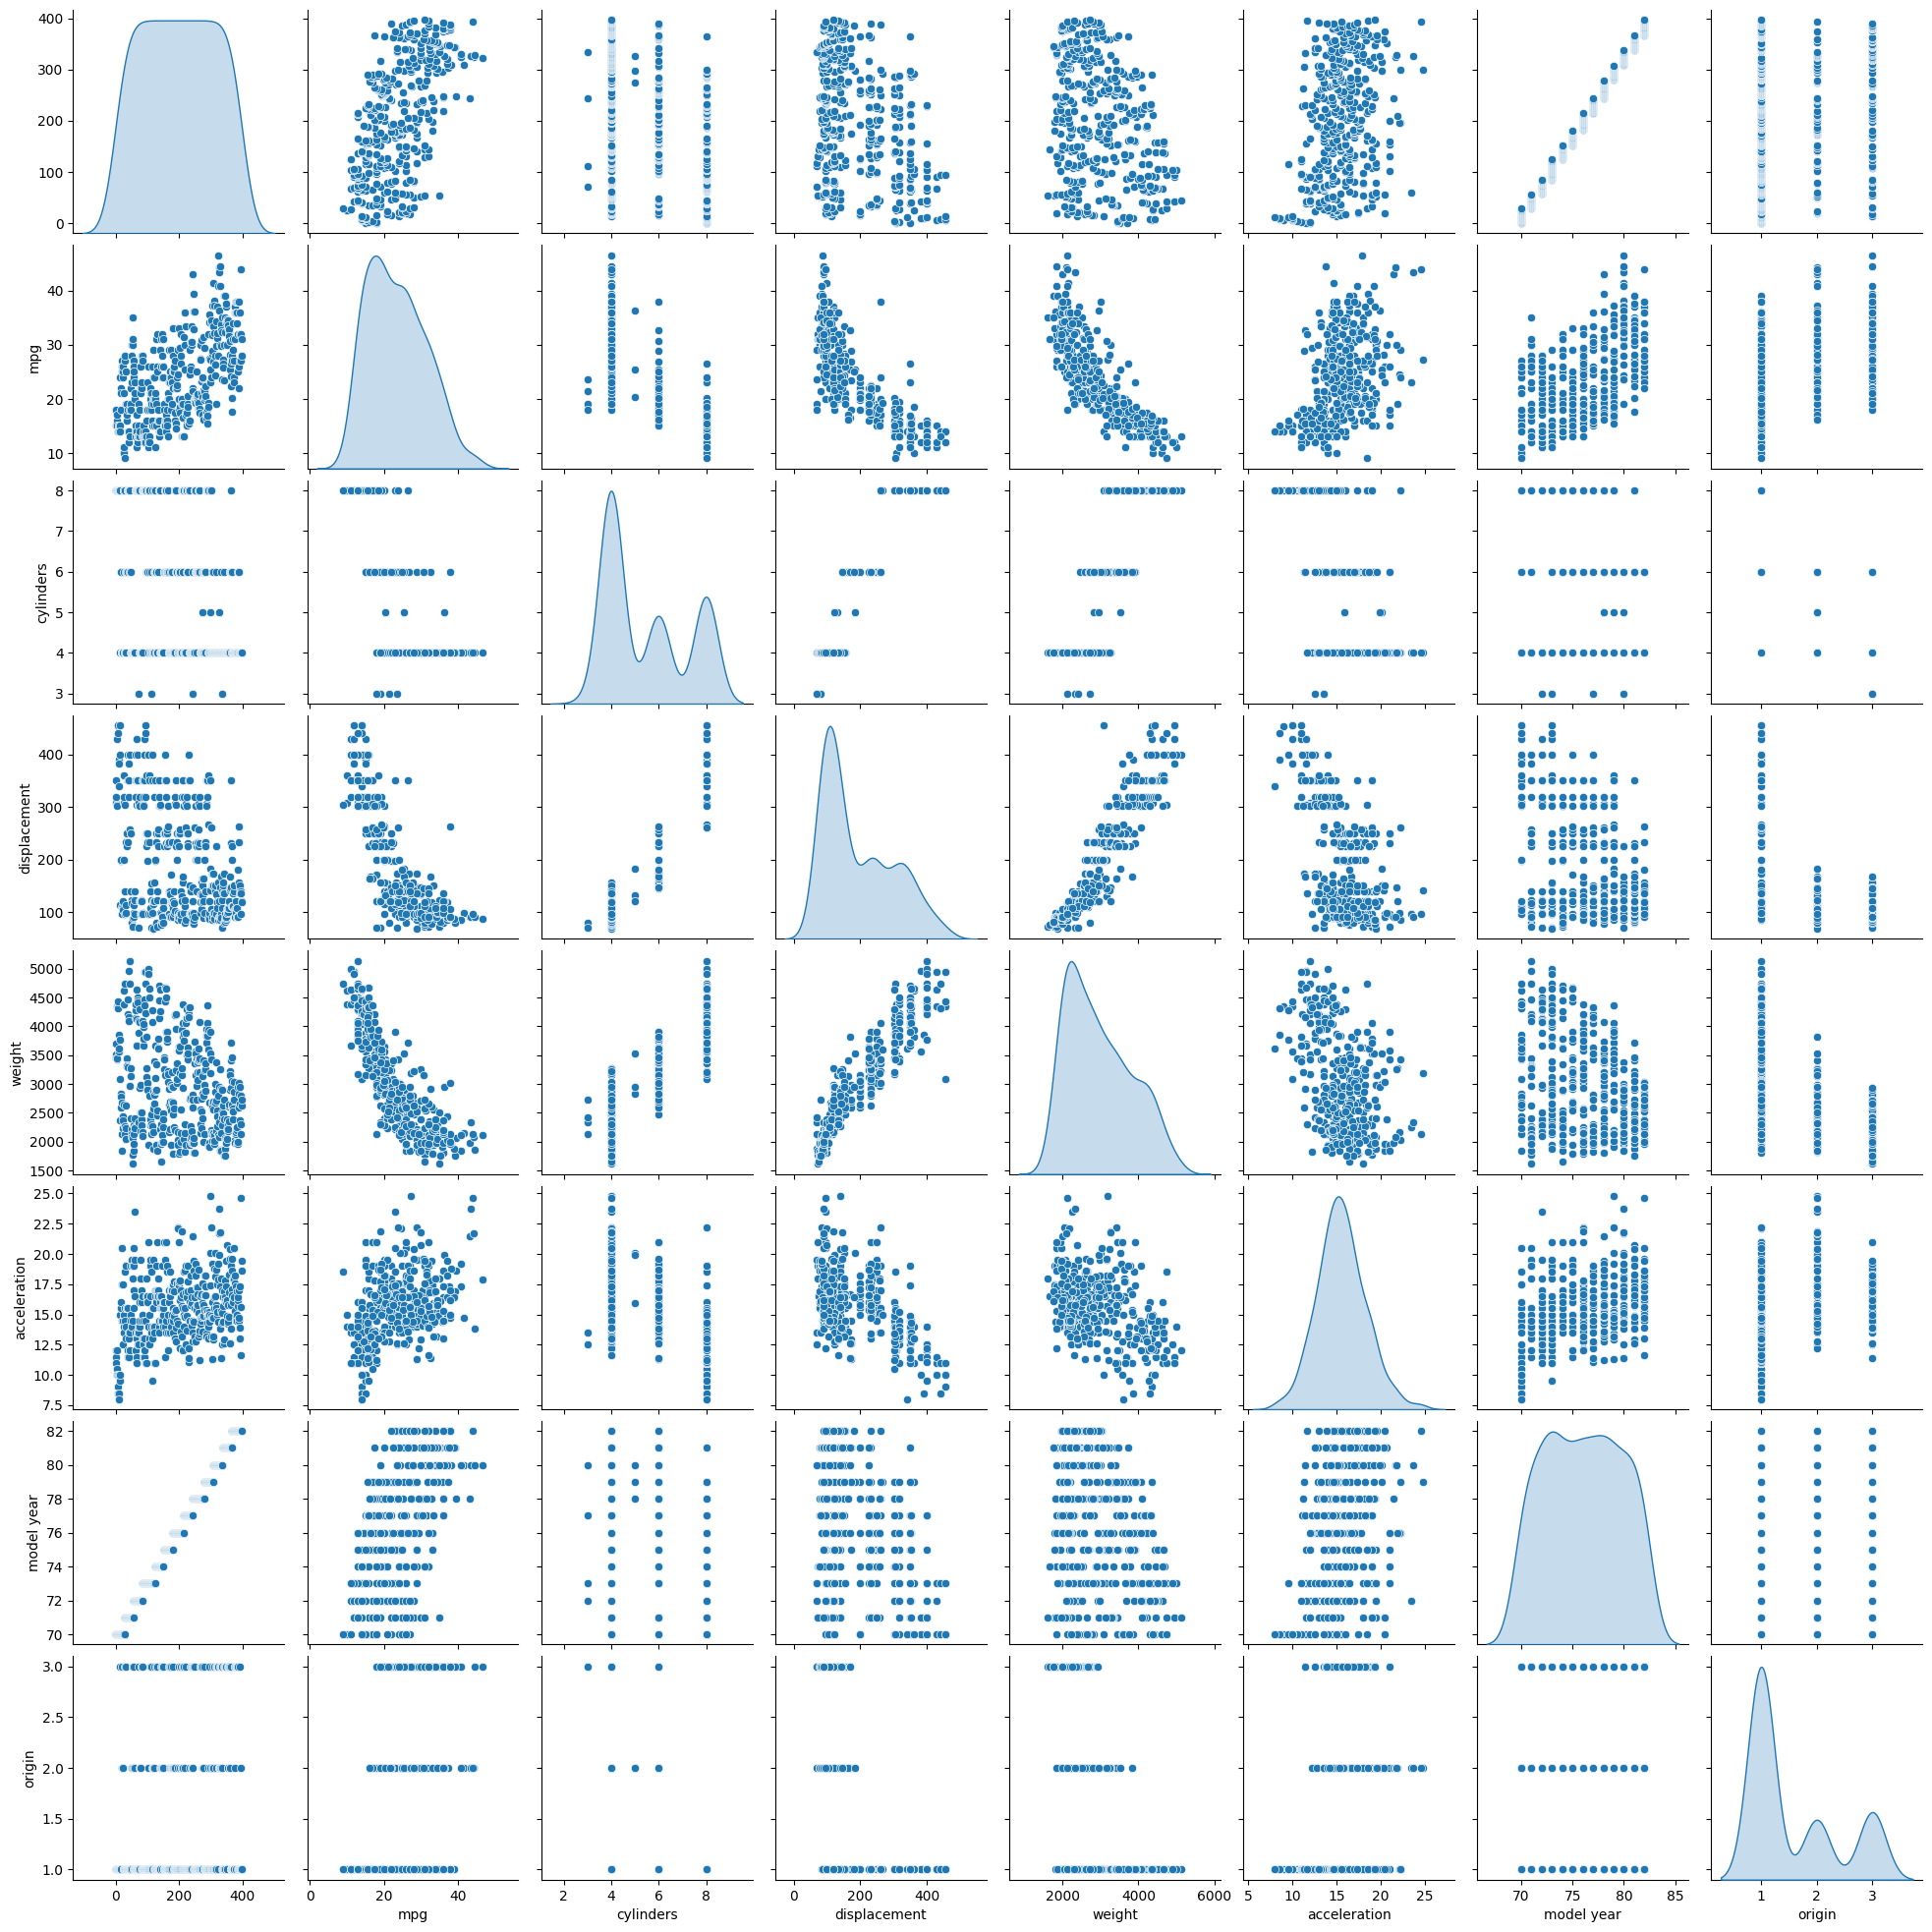

In [23]:
sns.pairplot(dfpa, diag_kind="kde")

In [59]:
# Drop irrelevant feaetures
df_cleaned = df.drop('car name')
dfpa_cleaned = dfpa.drop('car name', axis=1)

In [60]:
df_cleaned.dtypes
dfpa_cleaned.dtypes

                  int64
mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model year        int64
origin            int64
dtype: object

In [61]:
df = df.with_columns(
    pl.when(pl.col('horsepower')=="?")
    .then(None)
    .otherwise(pl.col('horsepower'))
    .cast(pl.Int64)
    .alias('horsepower')
)

ComputeError: cannot compare string with numeric type (i64)

In [62]:
print(type(dfpa_cleaned))
dfpa_cleaned.__class__

<class 'pandas.core.frame.DataFrame'>


pandas.core.frame.DataFrame

In [112]:
dfpa_cleaned['horsepower'] = pd.to_numeric(dfpa_cleaned['horsepower'], errors='coerce').fillna(dfpa_cleaned['horsepower'].median())

In [78]:
dfpa_cleaned=dfpa_cleaned.drop('', axis=1)

KeyError: "[''] not found in axis"

In [114]:
dfpa_cleaned.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.304020,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.222625,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [127]:
dfpa_cleaned['origin']=pd.Categorical(dfpa_cleaned['origin'])

In [129]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(dfpa_cleaned.drop(['mpg'], axis=1), dfpa_cleaned['mpg'], train_size=0.8, random_state=42)
numeric = X_train.select_dtypes(['number']).columns.to_list()
categoric = X_train.select_dtypes(exclude=['number']).columns.to_list()


In [116]:
print(numeric)
print(categoric)

['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year']
['origin']


In [137]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = pd.concat([pd.DataFrame(scaler.fit_transform(X_train[numeric]), columns=numeric), X_train[categoric]], axis=1)
X_test_scaled = pd.concat([pd.DataFrame(scaler.transform(X_test[numeric]), columns=numeric)], axis=1)

In [138]:
X_train_scaled.isna().sum()

cylinders       63
displacement    63
horsepower      63
weight          63
acceleration    63
model year      63
origin          63
dtype: int64

In [126]:
X_train.isna().sum()
dfpa_cleaned.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
dtype: int64

In [87]:
ols_glm = sm.GLM(y_train, X_train, family=sm.families.Gaussian(link=sm.families.links.Identity())).fit()
ols_glm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                    mpg   No. Observations:                  318
Model:                            GLM   Df Residuals:                      310
Model Family:                Gaussian   Df Model:                            7
Link Function:               Identity   Scale:                          11.961
Method:                          IRLS   Log-Likelihood:                -841.76
Date:                Sat, 07 Jun 2025   Deviance:                       3708.0
Time:                        13:07:11   Pearson chi2:                 3.71e+03
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9860
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -20.5593      5.511     -3.731      0.000     -31.361      -9.758
cylinders       -0.1568      0.383     -0.410      0.682      -0.907       0.593
displacement     0.0142      0.009      1.617      0.106      -0.003       0.031
horsepower      -0.0132      0.016     -0.836      0.403      -0.044       0.018
weight          -0.0067      0.001     -9.103      0.000      -0.008      -0.005
acceleration     0.0688      0.111      0.619      0.536      -0.149       0.286
model year       0.7950      0.061     13.066      0.000       0.676       0.914
origin           1.3230      0.322      4.107      0.000       0.692       1.954
================================================================================
"""

In [96]:
ols_pen = sm.GLM(y_train, X_train, family=sm.families.Gaussian(link=sm.families.links.Identity())).fit_regularized(method='elastic_net', alpha = 100
                                                                                                                   , L1_wt = 1)

# 2. Extract coefficients
coefs = ols_pen.params

# 3. Select features with non-zero coefficients
nonzero_features = coefs[coefs != 0].index
X_train_reduced = X_train[nonzero_features]

# 4. Refit standard OLS model on selected features
ols_refit = sm.OLS(y_train, sm.add_constant(X_train_reduced)).fit()

# 5. Get the summary
print(ols_refit.summary())
print(coefs)

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     643.9
Date:                Sat, 07 Jun 2025   Prob (F-statistic):          5.16e-112
Time:                        13:11:33   Log-Likelihood:                -850.52
No. Observations:                 318   AIC:                             1707.
Df Residuals:                     315   BIC:                             1718.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.2487      4.693     -3.675      0.0

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1464: UserWarning: Elastic net fitting did not converge
  warnings.warn("Elastic net fitting did not converge")


In [97]:
print(nonzero_features)

Index(['weight', 'model year'], dtype='object')


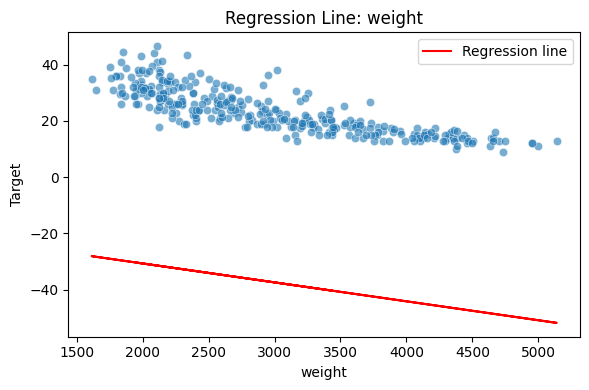

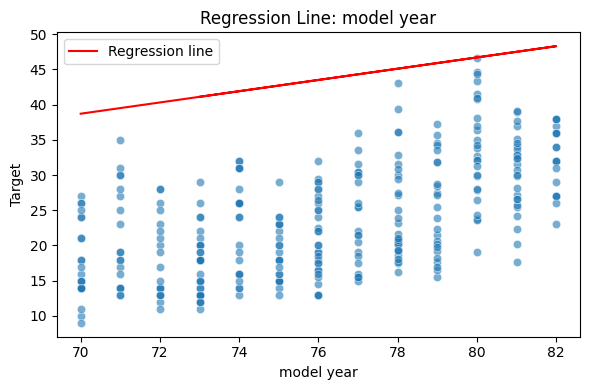

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the constant and coefficients
intercept = ols_refit.params['const']
coefs_no_const = ols_refit.params.drop('const')

# Loop over each selected feature
for feature in coefs_no_const.index:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_train_reduced[feature], y=y_train, alpha=0.6)

    # Plot the regression line
    x_vals = X_train_reduced[feature]
    y_vals = intercept + coefs_no_const[feature] * x_vals
    plt.plot(x_vals, y_vals, color='red', label='Regression line')

    plt.xlabel(feature)
    plt.ylabel("Target")
    plt.title(f"Regression Line: {feature}")
    plt.legend()
    plt.tight_layout()
    plt.show()